# CIFAR-10 CNN Progression with Keras 3 — PyTorch Backend

This workflow preserves both archived stages: the simple model receives five
epochs and the advanced model receives its documented 25-epoch budget. Only
the model selected from validation accuracy is evaluated on the test set.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports and reproducibility

In [3]:
import hashlib
import json
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
from keras import layers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

assert keras.backend.backend() == "torch"
print(
    f"Keras {keras.__version__}; backend={keras.backend.backend()}; "
    f"PyTorch {torch.__version__}"
)

Keras 3.15.1; backend=torch; PyTorch 2.13.0


## Load data and create the shared split

In [4]:
FAST_RUN = os.getenv("HELIO_FAST_RUN", "0") == "1"
SEED = 42
EPOCHS = 1 if FAST_RUN else 5
BATCH_SIZE = 64

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)

(x_development, y_development), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_development = y_development.reshape(-1)
y_test = y_test.reshape(-1)
all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=5000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

if FAST_RUN:
    train_indices = train_indices[:2000]
    validation_indices = validation_indices[:500]
    x_test = x_test[:500]
    y_test = y_test[:500]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)


assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: bfa7941b2b58be94
train=45,000, validation=5,000, test=10,000, epochs=5


## Inspect class coverage

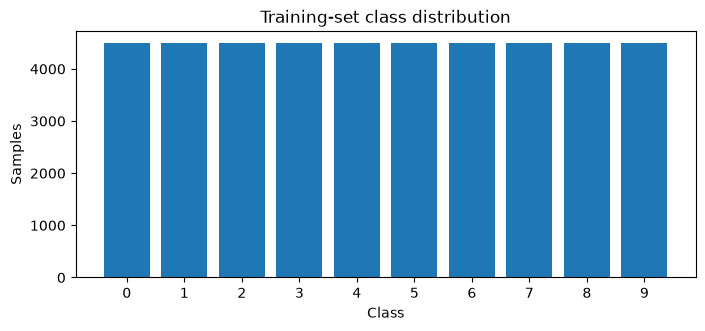

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Simple source model — five epochs

In [6]:
EPOCHS = 1 if FAST_RUN else 5

In [7]:
model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, 3),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Conv2D(32, 3, strides=2),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Flatten(),
        layers.Dense(100),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dropout(0.5),
        layers.Dense(10),
    ],
    name="cifar10_simple",
)

Model: "cifar10_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       627,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,990 (2.42 MB)

 Trainable params: 633,694 (2.42 MB)

 Non-trainable params: 296 (1.16 KB)

...

704/704 - 15s - 21ms/step - accuracy: 0.6078 - loss: 1.1013 - val_accuracy: 0.5500 - val_loss: 1.3677


Epoch 4/5


704/704 - 15s - 21ms/step - accuracy: 0.6495 - loss: 0.9937 - val_accuracy: 0.6408 - val_loss: 1.0136


Epoch 5/5


704/704 - 15s - 21ms/step - accuracy: 0.6760 - loss: 0.9131 - val_accuracy: 0.6568 - val_loss: 0.9964


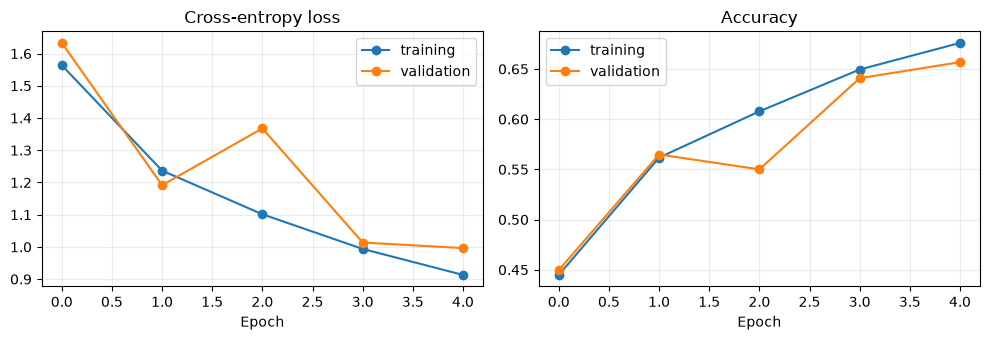

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history["loss"], marker="o", label="training")
axes[0].plot(history.history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history.history["accuracy"], marker="o", label="training")
axes[1].plot(history.history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
simple_model = model
simple_history = {key: list(value) for key, value in history.history.items()}
simple_validation = float(max(history.history["val_accuracy"]))

## Advanced source model — 25 epochs

In [10]:
EPOCHS = 1 if FAST_RUN else 25

In [11]:
model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3), layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Conv2D(64, 3, strides=2), layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Conv2D(128, 3, strides=2), layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1), layers.Dropout(0.2),
        layers.Flatten(), layers.Dense(600), layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1), layers.Dropout(0.25),
        layers.Dense(150), layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1), layers.Dropout(0.5),
        layers.Dense(10),
    ],
    name="cifar10_advanced",
)

Model: "cifar10_advanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 600)            │     2,765,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 600)            │         2,400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 150)            │        90,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,954,204 (11.27 MB)

 Trainable params: 2,952,256 (11.26 MB)

 Non-trainable params: 1,948 (7.61 KB)

...

704/704 - 22s - 31ms/step - accuracy: 0.9429 - loss: 0.1646 - val_accuracy: 0.7390 - val_loss: 1.0593


Epoch 24/25


704/704 - 23s - 33ms/step - accuracy: 0.9465 - loss: 0.1575 - val_accuracy: 0.7292 - val_loss: 1.0413


Epoch 25/25


704/704 - 22s - 31ms/step - accuracy: 0.9425 - loss: 0.1674 - val_accuracy: 0.7450 - val_loss: 1.0578


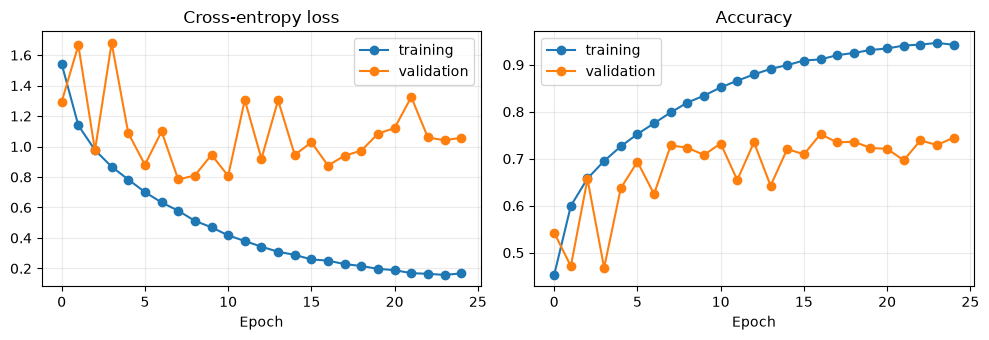

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history["loss"], marker="o", label="training")
axes[0].plot(history.history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history.history["accuracy"], marker="o", label="training")
axes[1].plot(history.history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
advanced_model = model
advanced_history = {key: list(value) for key, value in history.history.items()}
advanced_validation = float(max(history.history["val_accuracy"]))

## Compare the source progression

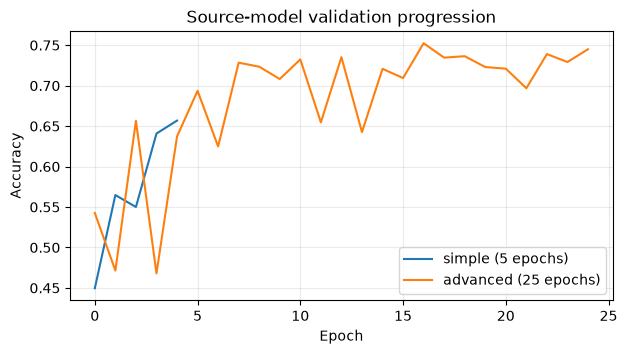

selected from validation evidence: advanced source model


In [14]:
if advanced_validation > simple_validation:
    selected_name, model = "advanced source model", advanced_model
else:
    selected_name, model = "simple source model", simple_model
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(simple_history["val_accuracy"], label="simple (5 epochs)")
ax.plot(advanced_history["val_accuracy"], label="advanced (25 epochs)")
ax.set(title="Source-model validation progression", xlabel="Epoch", ylabel="Accuracy")
ax.legend()
ax.grid(alpha=0.25)
plt.show()
print(f"selected from validation evidence: {selected_name}")

## Evaluate the selected source model once

test accuracy: 0.7456
              precision    recall  f1-score   support

           0      0.786     0.782     0.784      1000
           1      0.886     0.820     0.852      1000
           2      0.650     0.671     0.660      1000
           3      0.525     0.633     0.574      1000
           4      0.753     0.669     0.708      1000
           5      0.676     0.662     0.669      1000
           6      0.770     0.842     0.804      1000
           7      0.862     0.723     0.786      1000
           8      0.896     0.776     0.832      1000
           9      0.748     0.878     0.808      1000

    accuracy                          0.746     10000
   macro avg      0.755     0.746     0.748     10000
weighted avg      0.755     0.746     0.748     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "bfa7941b2b58be94", "test_accuracy": 0.7456}


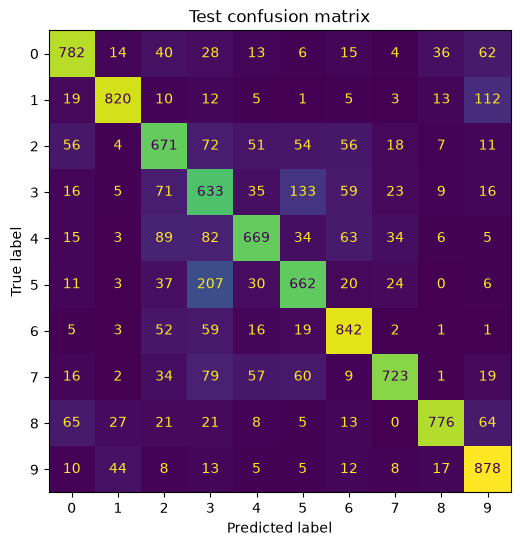

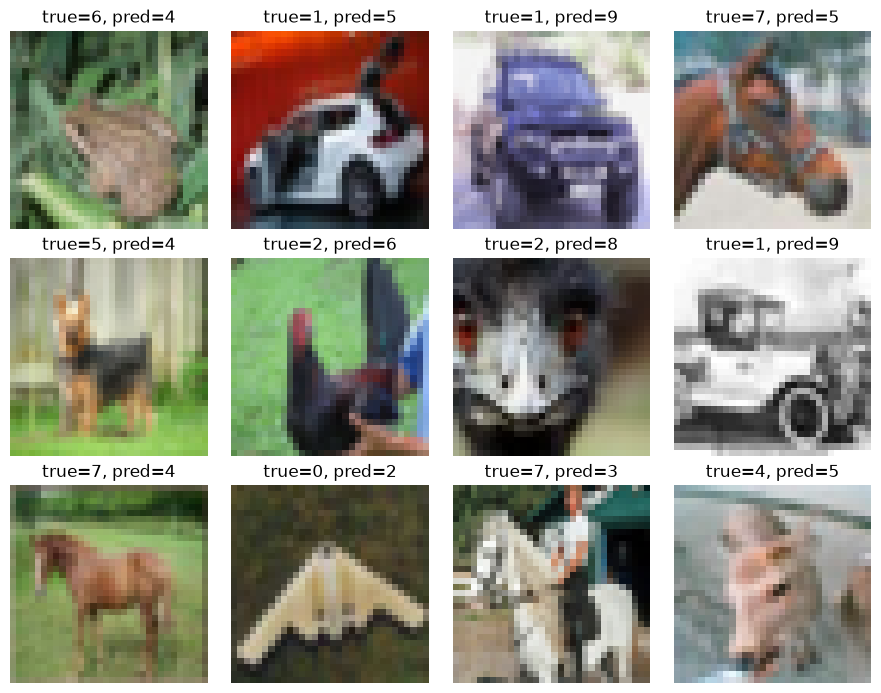

In [15]:
test_logits = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
test_predictions = test_logits.argmax(axis=1)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself in Keras

Change one choice at a time and keep the data split and evaluation unchanged:

- change the dropout in the advanced model.
- vary the third-stage filter count.
- compare how quickly the two models learn under a shorter budget.